In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42755 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42755/status,
Dashboard: http://127.0.0.1:42755/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44489,Workers: 0
Dashboard: http://127.0.0.1:42755/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36417,Total threads: 8
Dashboard: http://127.0.0.1:40343/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:46125,


In [15]:
import xarray as xr
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams['font.size'] = 13

profile_path = '/data/shared_data/Interp_Profiles/regional/TP/TAO/TAO_WO_2013_CTD_daily.nc'
ds = xr.open_dataset(profile_path)

In [17]:
import numpy as np
std_dev = np.sqrt(1/ds.prof_Sweight)
std_dev = std_dev*1.5
ds['prof_Sweight'] = 1/(std_dev**2)

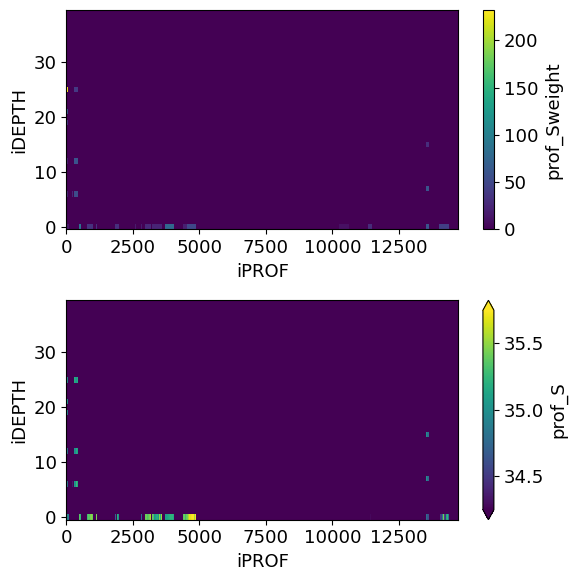

In [18]:
fig,ax = plt.subplots(figsize=(6, 6), nrows=2)

ds.prof_Sweight.T.plot(ax=ax[0])
ds.prof_S.T.plot(ax=ax[1],vmin=34.25,vmax=35.75,cmap='viridis')

plt.tight_layout()

In [19]:
profile_path = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_CTD_daily_ED.nc'
ds.to_netcdf(profile_path, mode='w', engine='netcdf4')

In [20]:
client.shutdown()